In [22]:
import numpy as np
import pandas as pd
import random
import json
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, fbeta_score, log_loss, confusion_matrix 
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE
from skmultilearn.problem_transform import LabelPowerset
from sklearn.multioutput import MultiOutputClassifier, ClassifierChain
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.model_selection import GridSearchCV
from sklearn.impute import KNNImputer
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import multilabel_confusion_matrix
from sklearn.metrics import hamming_loss
from sklearn.metrics import classification_report
from itertools import product

import sys
import math
import shap
import xgboost as xgb

sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import read_data, convert_multiple_cases, encode_cyclical, optimal_threashold_fbeta_scalar

import warnings
warnings.filterwarnings("ignore")

NUTS0 = 'GR'
P = 'P1'
p = P.lower()

file1 = r'E:\Drive\NOA\MBD-Prediction\JRC Interpretability\Greece\data\CMacedonia\GR_CMacedonia_WNV_Dataset_OP_2010_2023.csv'
file2 = r'E:\Drive\NOA\MBD-Prediction\JRC Interpretability\Greece\data\Thessaly\GR_Thessaly_WNV_Dataset_OP_2010_2023.csv'
file3 = r'E:\Drive\NOA\MBD-Prediction\JRC Interpretability\Greece\data\Thrace\GR_Thrace_WNV_Dataset_OP_2010_2023.csv'
file4 = r'E:\Drive\NOA\MBD-Prediction\JRC Interpretability\Greece\data\Attica\GR_Attica_WNV_Dataset_OP_2010_2023.csv'

dataset1 = read_data(file1)
dataset2 = read_data(file2)
dataset3 = read_data(file3)
dataset4 = read_data(file4)


dataset1.head()

dataset2.head()

dataset3.head()

dataset4.head()

dataset = pd.concat([dataset1, dataset2, dataset3, dataset4])

dataset.reset_index(drop = True, inplace = True)

print(dataset.shape)

(3696, 112)


In [2]:
dataset.head()

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases
0,EL521,2010,1,22.217953,40.552111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.230096,5.166060,9.054669,14.068100,14.068100,2.490562,0.057874,0.608776,1.209346,1.209346,6.360329,2.696421,4.831723,7.638723,7.638723,0.104074,15.201481,9.578581,51.883864,98.485803,288.402406,1461.841477,31.0,1.000000,14.333333,19.666667,40.972222,832.120329,37.0,-11.0,48.0,5.500000,23.500000,24.000000,4.166667,1455.0,296.0,45.0,62.908014,664.0,194.0,259.0,576.0,31,36,30,12,12,1,6,7,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.0,1.0,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,11723.0,44888.0,13557.0,70168.0,11361.0,44491.0,16024.0,71876.0,2098.63,4287.0,4163.0,0
1,EL522,2010,1,23.139033,40.693632,0.240287,0.059537,-0.141941,-0.059537,0.215547,0.069956,-0.106000,-0.069956,0.049703,0.064085,0.084328,0.064085,11.844360,7.145869,9.818153,15.604511,15.604511,2.833916,-0.061709,0.147210,1.468130,1.468130,7.339138,3.542080,4.982681,8.536321,8.536321,0.190938,15.922969,9.407951,37.402003,76.781372,290.599935,1330.804946,31.0,1.000000,16.083333,21.166667,45.035461,888.265248,42.0,-5.0,47.0,7.166667,9.500000,27.333333,5.666667,1324.0,291.0,35.0,66.632744,587.0,184.0,280.0,547.0,31,30,30,10,10,1,6,6,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.0,1.0,23002.186702,4365.002425,29,275.024254,879.827019,205.433801,2.743756,854.107751,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,87281.0,374669.0,80103.0,542053.0,83839.0,403005.0,104992.0,591836.0,21520.33,13373.0,15210.0,0
2,EL523,2010,1,22.762317,41.016275,0.270784,-0.039708,-0.307282,0.039708,0.264906,-0.037696,-0.294932,0.037696,0.050738,0.048113,0.097949,0.048113,10.279993,7.289129,9.855217,16.110757,16.110757,2.501269,-1.712222,-0.396863,0.873001,0.873001,6.390631,2.788454,4.729177,8.491879,8.491879,-1.350000,17.236087,9.239469,47.729387,98.428751,284.920463,1386.197739,31.0,1.000000,16.041667,22.916667,44.070513,929.187899,44.0,-8.0,52.0,6.666667,9.333333,27.666667,5.333333,1381.0,286.0,41.0,63.457161,604.0,204.0,300.0,550.0,31,36,30,12,12,3,5,8,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,838.981974,55.964179,0,51.972498,21.046828,155.354599,0.0,1.0,22771.829003,3753.170334,32,324.927224,972.921816,192.844

In [3]:
dataset = encode_cyclical(dataset, 'month', 12)

In [4]:
dataset.cases.sum()

1724

In [5]:
dataset = dataset.query('month >= 5 & month <= 11')
dataset.reset_index(drop=True, inplace=True)

In [6]:
dataset.shape

(2156, 114)

In [7]:
dataset.cases.sum()

1724

In [8]:
X = dataset.select_dtypes(exclude=['object']).drop(columns=['cases'])
y = dataset['cases']

In [9]:
n_folds = 10
k_fold = StratifiedKFold(n_splits = n_folds, shuffle = True, random_state = 0)
#k_fold = KFold(n_splits = n_folds, shuffle = True, random_state = 0)

In [10]:
# features_to_remove = ['x', 'y', 'year', 'month',
#                       'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std',
#                       'lc_prop1', 'lc_prop2', 'lc_prop3','lc_type1','lc_type3', 'lc_type4', 'lc_type5',
#                       'distance_to_coast_min', 'distance_to_river_min', 'slope_mean_1km_min', 'aspect_mean_200m_min', 'elevation_mean_1km_min', 'hillshade_mean_1km_min', 'fs_area_1km_min', 'flow_accu_200m_min', 
#                       'distance_to_coast_max', 'distance_to_river_max', 'slope_mean_1km_max', 'aspect_mean_200m_max', 'elevation_mean_1km_max', 'hillshade_mean_1km_max', 'fs_area_1km_max', 'flow_accu_200m_max',]

features_to_remove = ['x', 'y', 'year', 'month',]
feature_names = X.select_dtypes(exclude=['object']).drop(columns = features_to_remove).columns
print(feature_names.to_list())

['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day_mean', 'lst_jan_day_mean', 'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_night_mean', 'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean', 'lst_mean', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'monthly_lst_min', 'monthly_lst_max', 'rainfall_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_month', 'acc_rainfall_jan', 'mosq_pred_acc', 'mosq_pred_mean', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type1', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m'

In [11]:
fold_counter = 0
y_train_list = []
y_test_list = []
y_train_prob_list = []
y_test_prob_list = []

for train_idx, test_idx in k_fold.split(X, y):
    print(f'Fold: {fold_counter+1}/{n_folds}')

    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]

    data_train = convert_multiple_cases(data_train, target_col='cases')
    #data_train['cases'] = data_train['cases'].apply(lambda x: 1 if x > 0 else 0)
    data_test['cases'] = data_test['cases'].apply(lambda x: 1 if x > 0 else 0)

    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)

    sum_negatives = data_train['cases'].value_counts().get(0)
    sum_positives = data_train['cases'].value_counts().get(1)

    params = {
        "objective": "binary:logistic",
        "device": "gpu", 
        "eval_metric": "logloss",
        "learning_rate": 0.15,
        "min_split_loss": 0.5,
        "max_depth": 3, 
        "reg_alpha": 0.5,
        "reg_lambda": 0.5,
        "min_child_weight": 1.5,
        "scale_pos_weight": sum_negatives/sum_positives, 
    }


    X_train = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])
    X_test = data_test.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])

    y_train = data_train['cases']
    y_test = data_test['cases']

    print(f"Training set 0/1 Ratio: {(data_train['cases'].value_counts().get(0) / data_train['cases'].value_counts().get(1)):.2f}")
    print(f"Test set 0/1 Ratio: {(data_test['cases'].value_counts().get(0) / data_test['cases'].value_counts().get(1)):.2f}")
    
    scaler = MinMaxScaler(feature_range = (-1, 1))
    #scaler = RobustScaler()
    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
            
    imputer = KNNImputer()
    imputer.fit(X_train)
    X_train_imputed = imputer.transform(X_train_scaled)
    X_test_imputed = imputer.transform(X_test_scaled)

    model = xgb.XGBClassifier(**params)   
    trained_model = model.fit(X_train_imputed, y_train)

    y_train_prob = trained_model.predict_proba(X_train_imputed)
    y_test_prob = trained_model.predict_proba(X_test_imputed)

    y_train_list.append(y_train)
    y_test_list.append(y_test)
    y_train_prob_list.append(y_train_prob)
    y_test_prob_list.append(y_test_prob)
    fold_counter += 1

Fold: 1/10
Training set 0/1 Ratio: 1.05
Test set 0/1 Ratio: 5.75
Fold: 2/10
Training set 0/1 Ratio: 1.04
Test set 0/1 Ratio: 5.75
Fold: 3/10
Training set 0/1 Ratio: 1.07
Test set 0/1 Ratio: 5.75
Fold: 4/10
Training set 0/1 Ratio: 1.08
Test set 0/1 Ratio: 5.75
Fold: 5/10
Training set 0/1 Ratio: 1.11
Test set 0/1 Ratio: 5.75
Fold: 6/10
Training set 0/1 Ratio: 1.09
Test set 0/1 Ratio: 5.55
Fold: 7/10
Training set 0/1 Ratio: 1.04
Test set 0/1 Ratio: 5.72
Fold: 8/10
Training set 0/1 Ratio: 1.05
Test set 0/1 Ratio: 5.72
Fold: 9/10
Training set 0/1 Ratio: 1.08
Test set 0/1 Ratio: 5.72
Fold: 10/10
Training set 0/1 Ratio: 1.05
Test set 0/1 Ratio: 5.72


In [12]:
y_train_true = np.concatenate(y_train_list, axis=0)
y_test_true = np.concatenate(y_test_list, axis=0)

y_train_proba = np.concatenate(y_train_prob_list, axis = 0)
y_test_proba = np.concatenate(y_test_prob_list, axis = 0)

In [13]:
train_loss = log_loss(y_train_true, y_train_proba[:, 1])
print(f"Train Logloss: {train_loss:.4f}")

test_loss = log_loss(y_test_true, y_test_proba[:, 1])
print(f"Test Loss: {test_loss:.4f}")

Train Logloss: 0.0877
Test Loss: 0.2178


In [14]:
classification_thresholds = optimal_threashold_fbeta_scalar(y_train_proba[:,1], y_train_true, beta = 2, round_factor = 2)
print(classification_thresholds)

0.43


In [15]:
thr = classification_thresholds

In [16]:
y_train_pred = np.where(y_train_proba[:,1] > thr, 1, 0)
y_test_pred = np.where(y_test_proba[:,1] > thr, 1, 0)

In [17]:
print(classification_report(y_test_true, y_test_pred, output_dict=False))

              precision    recall  f1-score   support

           0       0.96      0.93      0.94      1835
           1       0.65      0.78      0.71       321

    accuracy                           0.90      2156
   macro avg       0.81      0.85      0.83      2156
weighted avg       0.91      0.90      0.91      2156



In [18]:
'''
MCM = [[TN, FP],
       [FN, TP]]
'''


cm = confusion_matrix(y_test_true, y_test_pred)

print(cm)

[[1702  133]
 [  72  249]]


In [19]:
data_train_shap = dataset.copy()
#data_train_shap = convert_multiple_cases(data_train_shap, target_col='cases')
data_train_shap['cases'] = data_train_shap['cases'].apply(lambda x: 1 if x > 0 else 0)

X_train = data_train_shap.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])
y_train = data_train_shap['cases']

sum_negatives = data_train_shap['cases'].value_counts().get(0)
sum_positives = data_train_shap['cases'].value_counts().get(1)

scaler = MinMaxScaler(feature_range = (-1, 1))
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
            
imputer = KNNImputer()
imputer.fit(X_train)
X_train_imputed = imputer.transform(X_train_scaled)
X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns)


In [20]:
# Tree explainer

# curently not working with multioutput models

params = {
        "objective": "binary:logistic",
        "device": "gpu", 
        "eval_metric": "logloss",
        "learning_rate": 0.15,
        "min_split_loss": 0.5,
        "max_depth": 3, 
        "reg_alpha": 0.5,
        "reg_lambda": 0.5,
        "min_child_weight": 1.5,
        "scale_pos_weight": sum_negatives/sum_positives, 
    }

model = xgb.XGBClassifier(**params)   
trained_model = model.fit(X_train_imputed, y_train)

tree_explainer = shap.TreeExplainer(model)
#tree_shap_values = tree_explainer.shap_values(X_train_imputed)
tree_shap_values = tree_explainer(X_train_imputed)

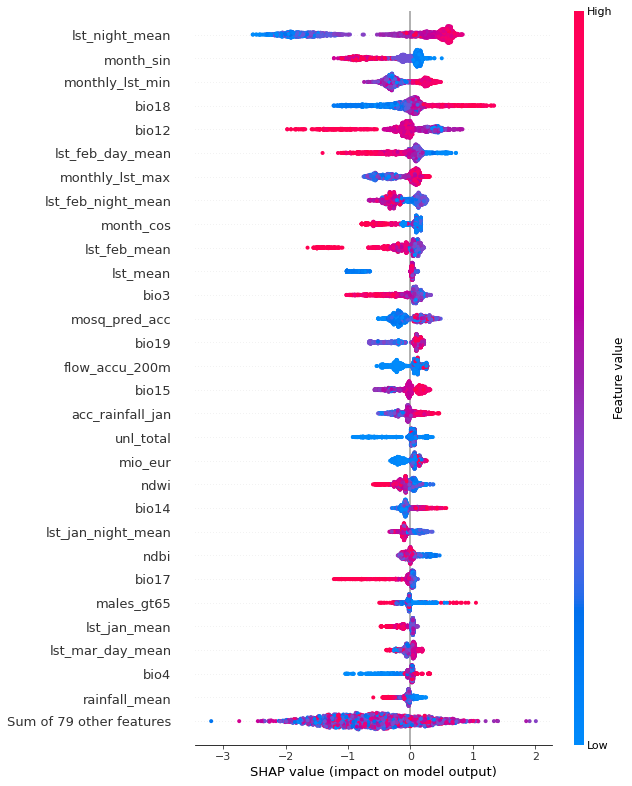

In [30]:
shap.plots.beeswarm(shap_values = tree_shap_values, max_display=30)

In [23]:
# shap_values_path = r'E:\Drive\NOA\MBD-Prediction\JRC Interpretability\Greece\data\ValuesShap\GR_OP_2010-2023_Tree_Shapely_Values.npz'

# np.savez(shap_values_path, *tree_shap_values)

# # shap_values = []
# # loaded_shap_values = np.load(shap_values_path)

# # for key in loaded_shap_values.keys():
# #     shap_values.append(loaded_shap_values[key])

In [31]:
X_train_imputed.shape

(2156, 108)

In [32]:
tree_shap_values.shape

(2156, 108)

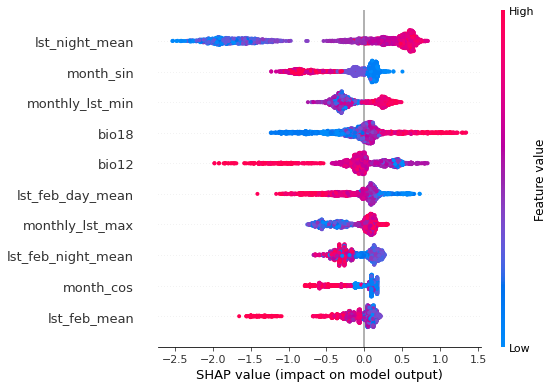

In [33]:
shap.summary_plot(tree_shap_values, feature_names = X_train_imputed.columns, features = X_train_imputed, max_display=10)

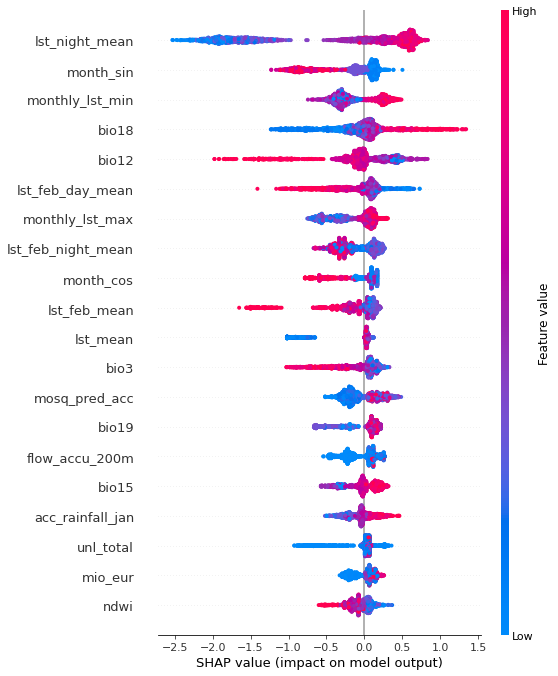

In [34]:
shap.summary_plot(tree_shap_values.values, feature_names = X_train.columns, features = tree_shap_values.data)

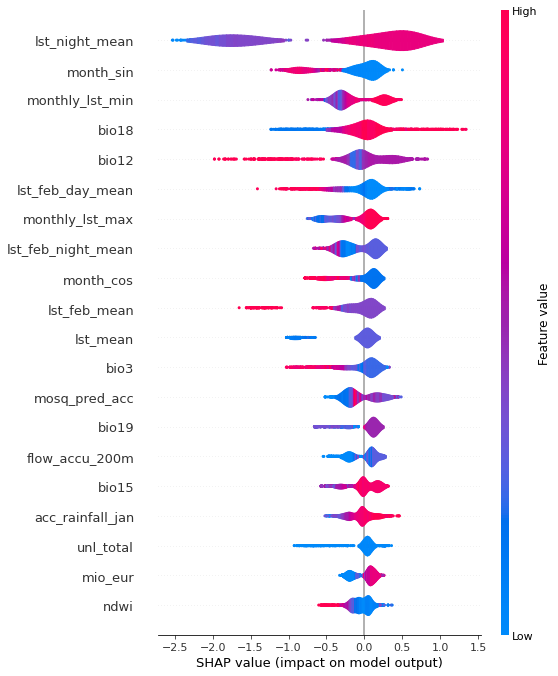

In [35]:
shap.summary_plot(tree_shap_values, feature_names = X_train.columns, features = X_train_imputed, plot_type='violin')

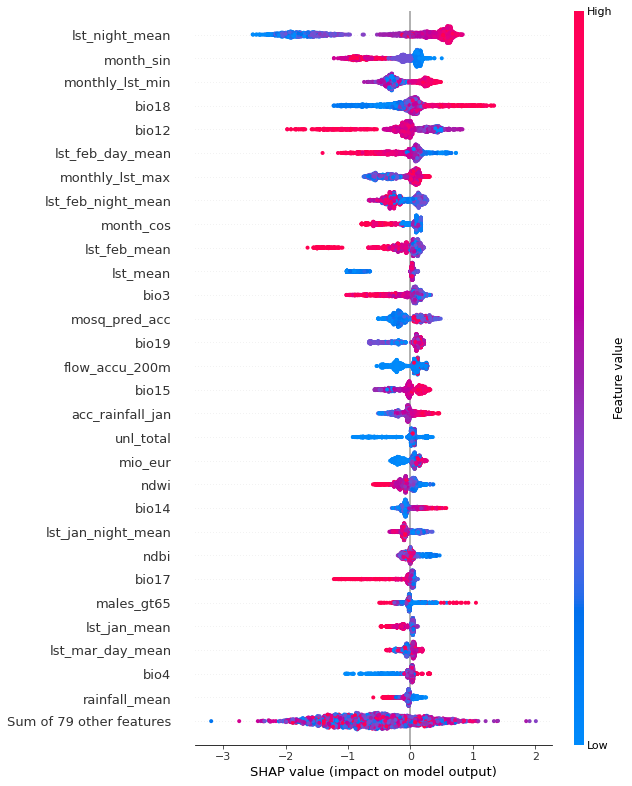

In [38]:
shap.plots.beeswarm(shap_values = tree_shap_values, max_display=30)

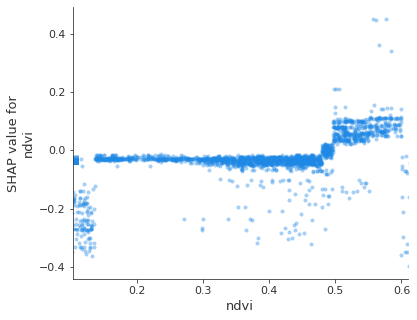

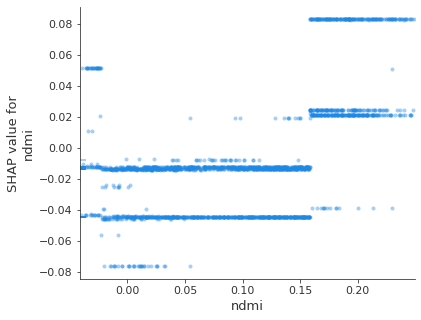

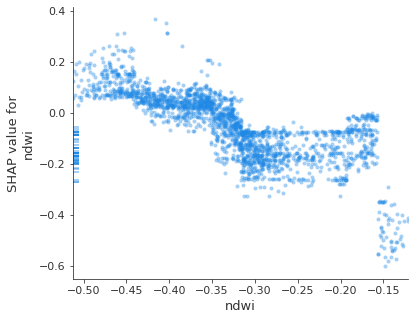

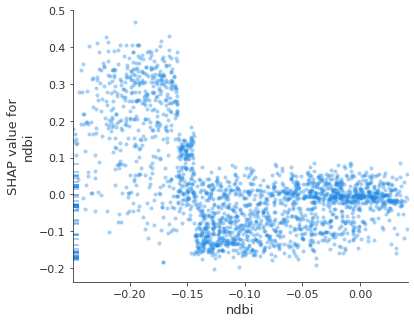

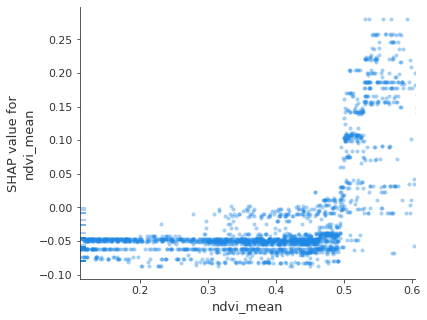

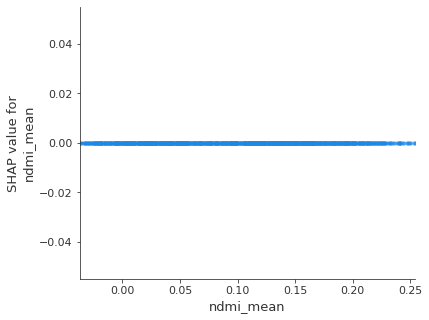

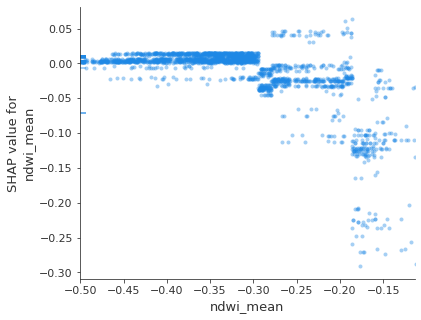

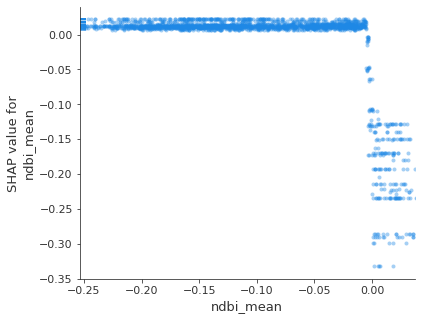

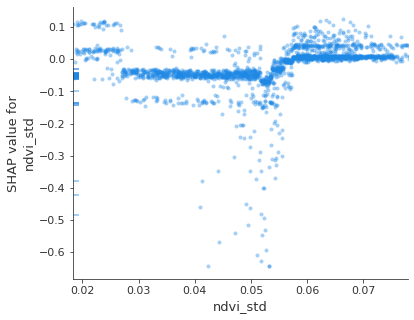

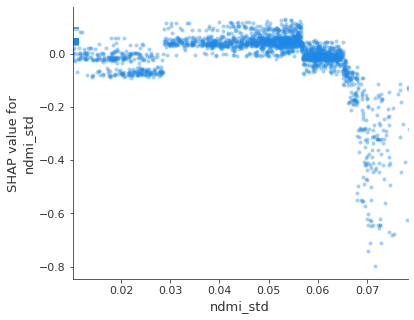

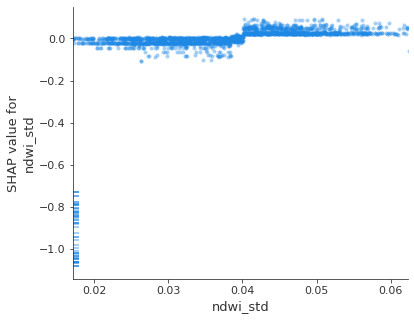

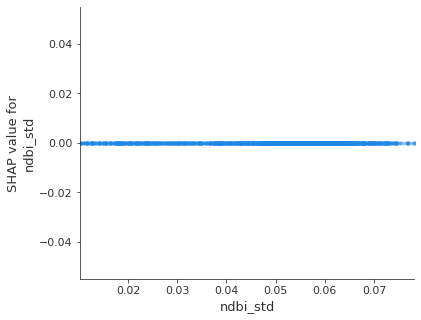

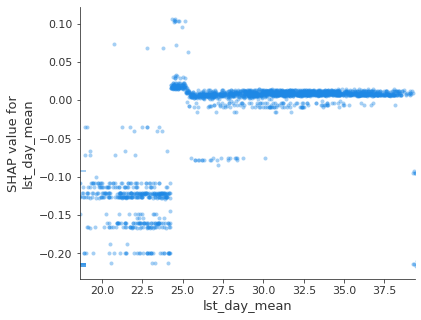

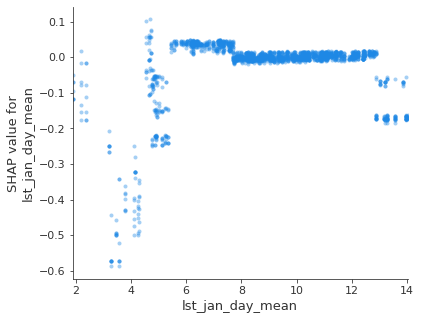

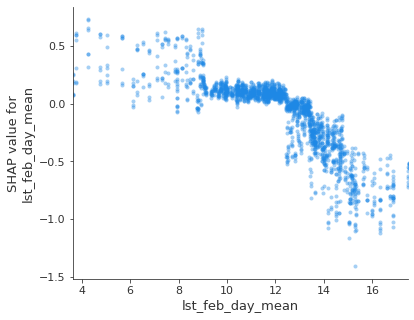

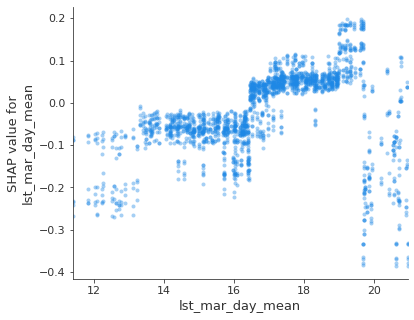

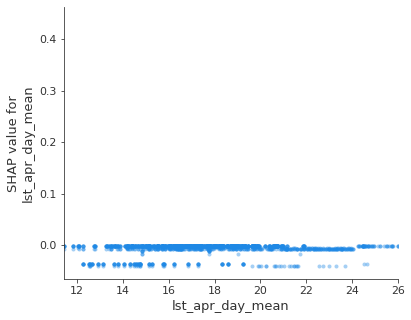

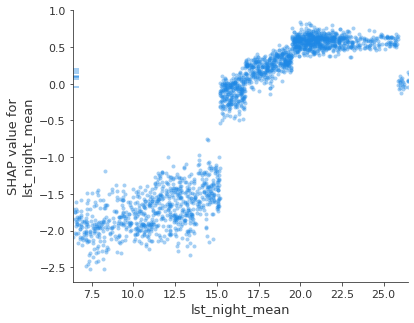

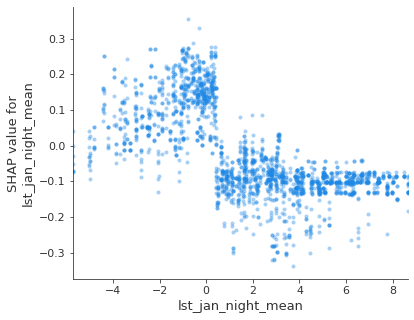

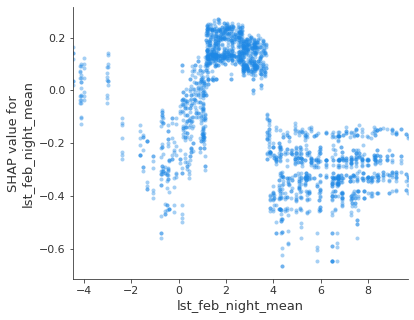

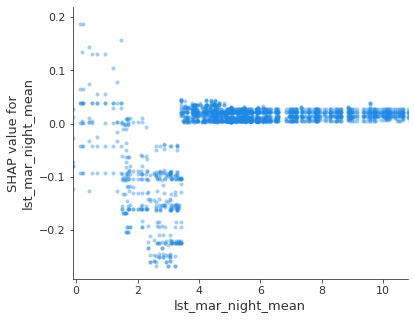

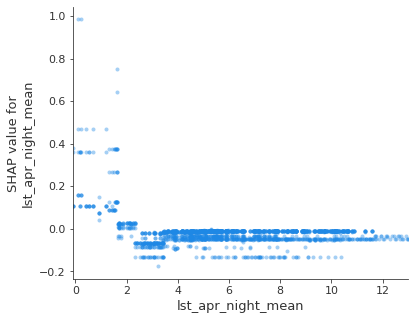

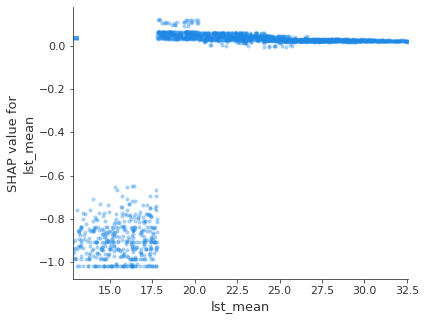

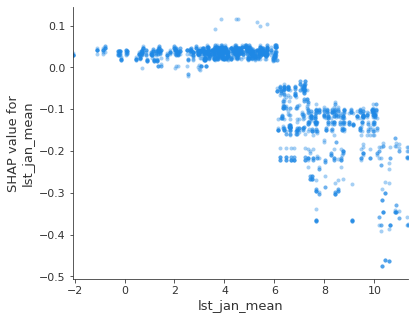

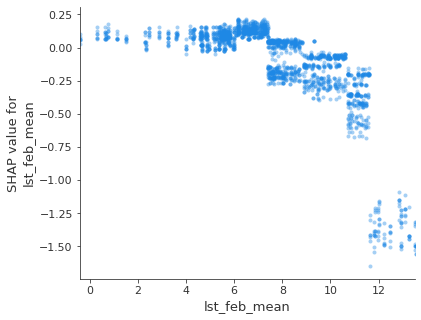

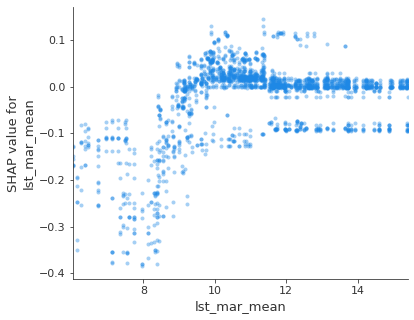

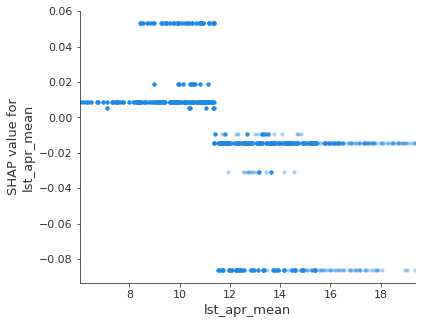

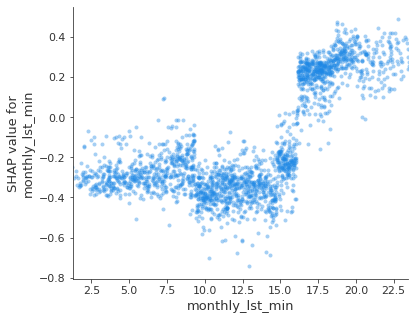

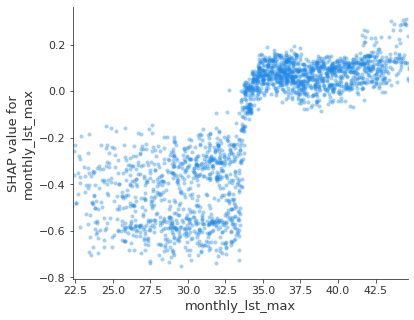

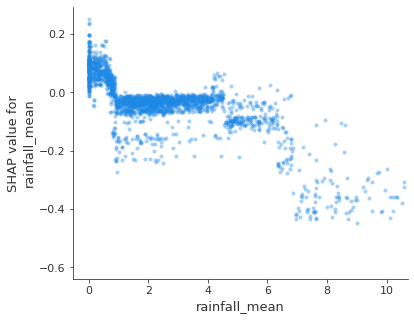

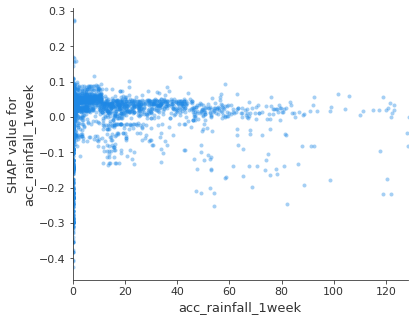

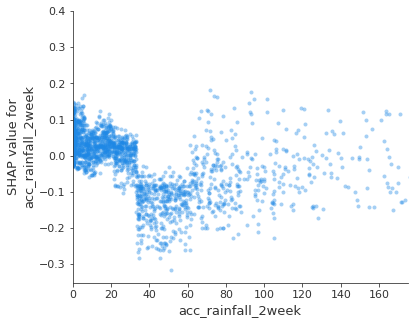

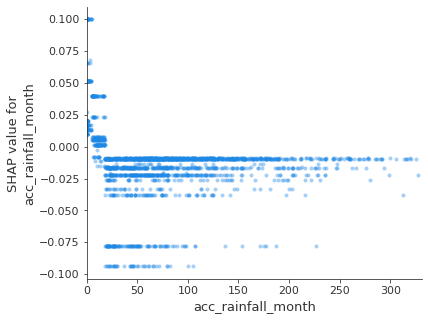

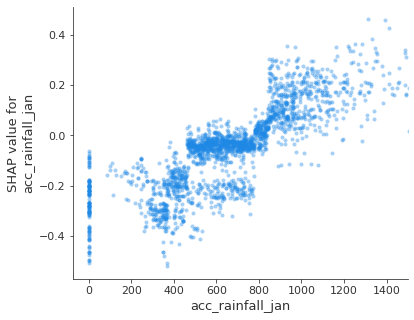

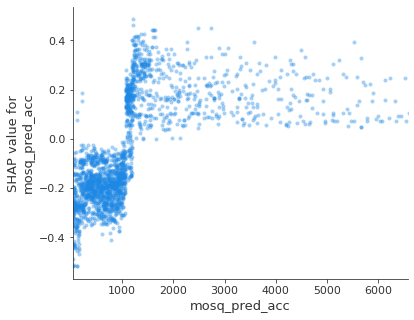

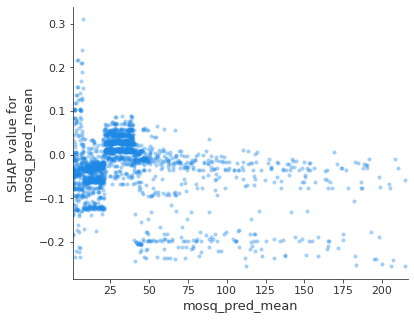

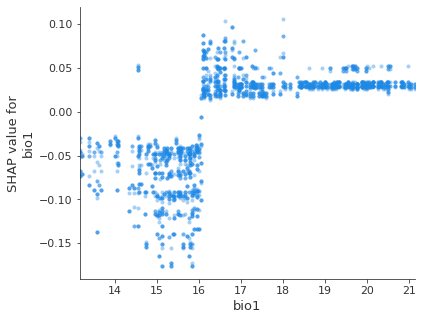

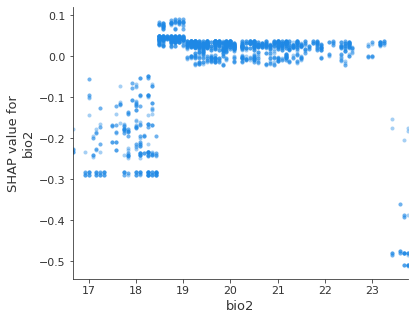

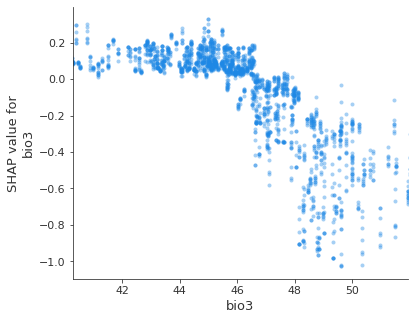

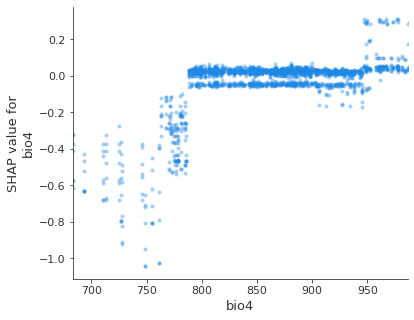

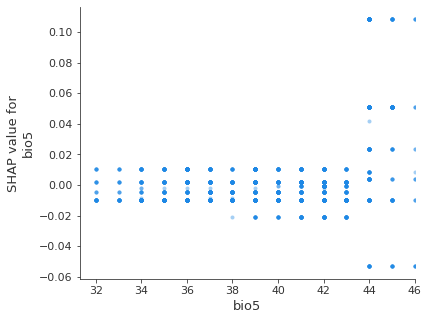

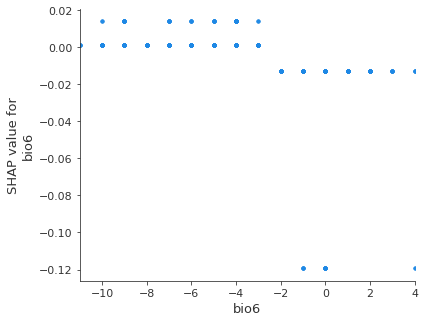

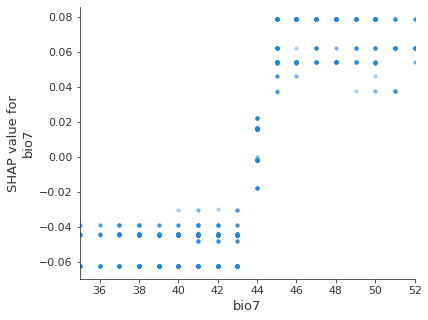

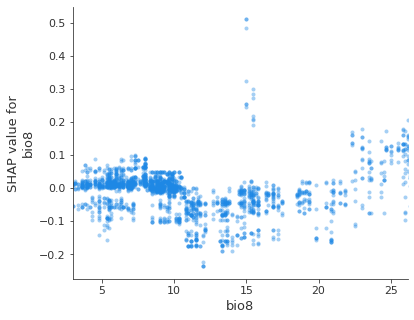

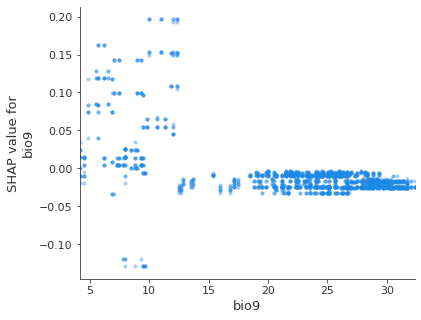

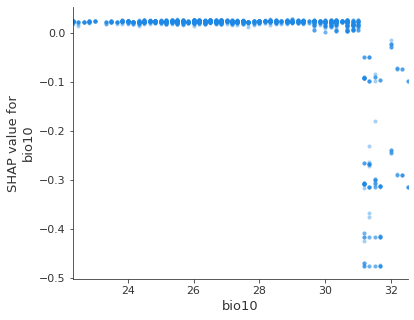

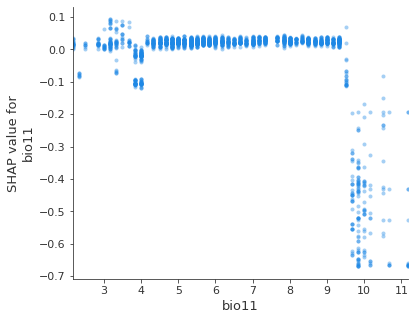

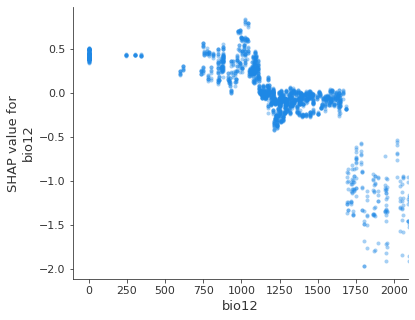

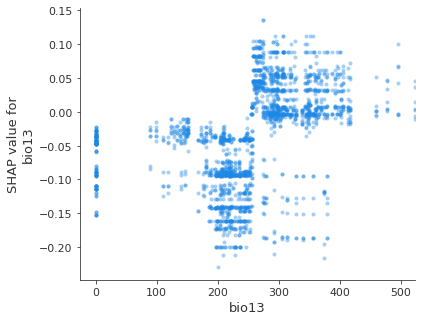

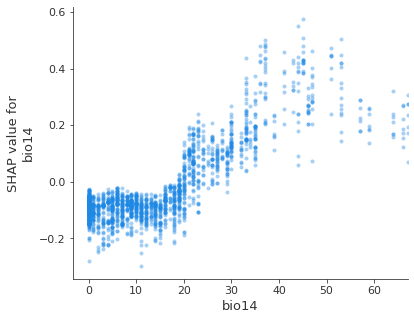

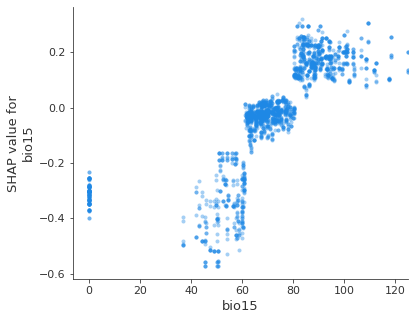

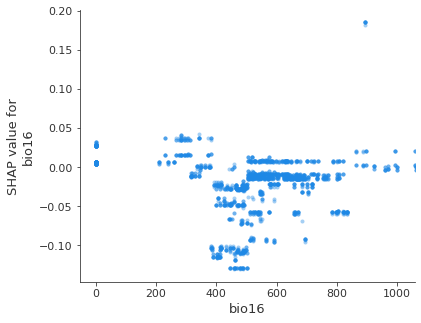

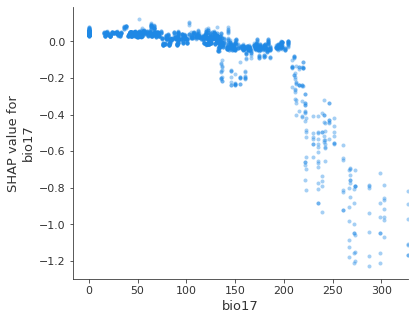

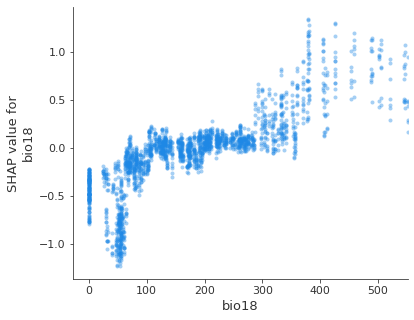

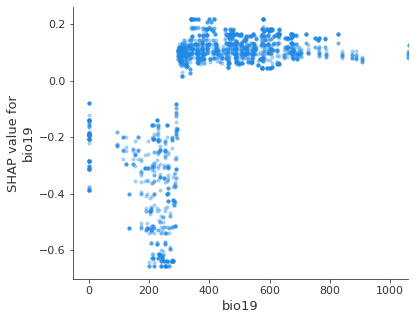

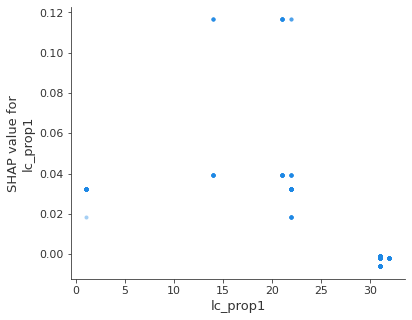

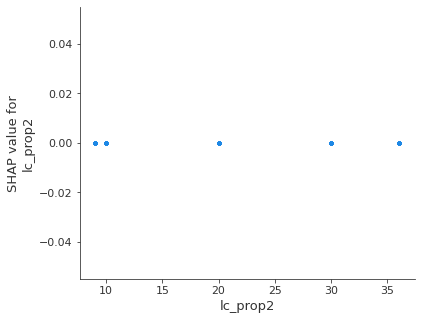

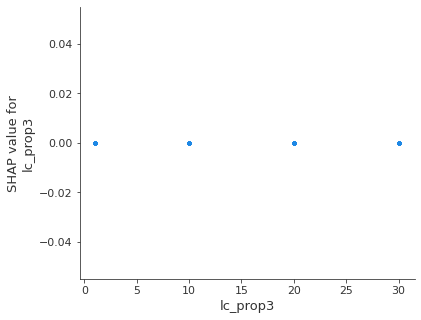

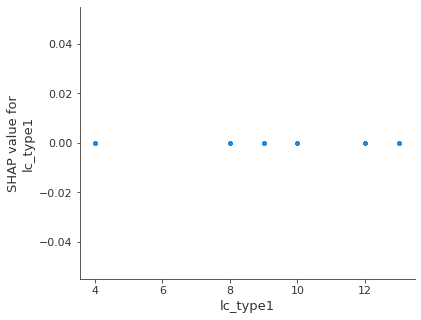

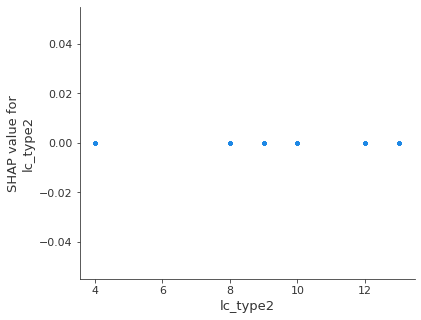

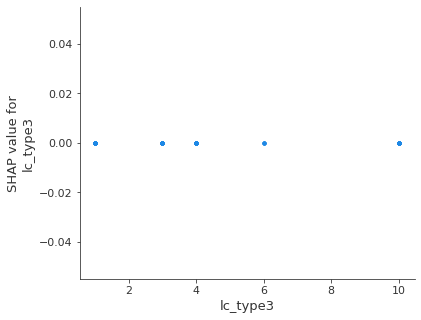

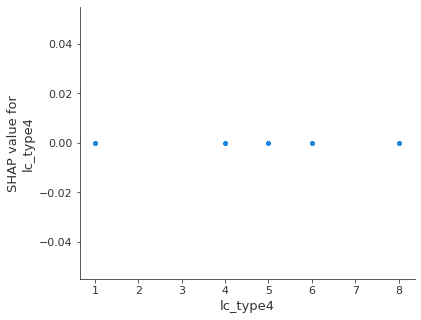

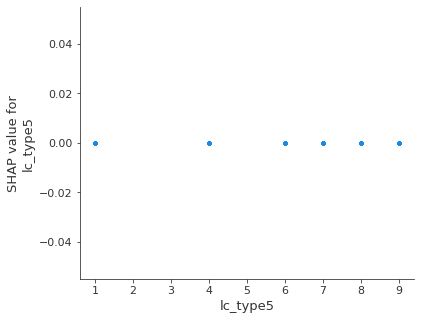

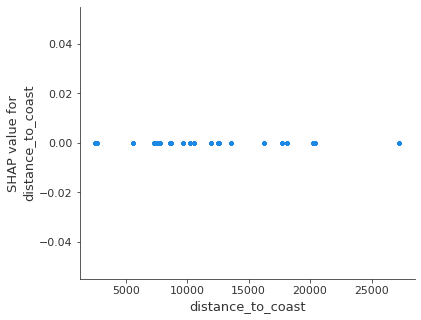

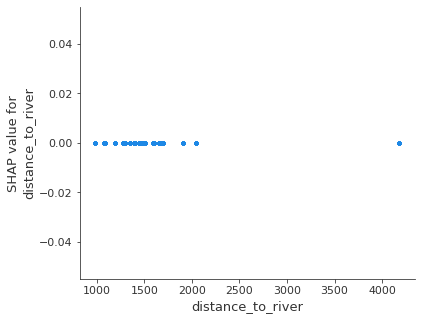

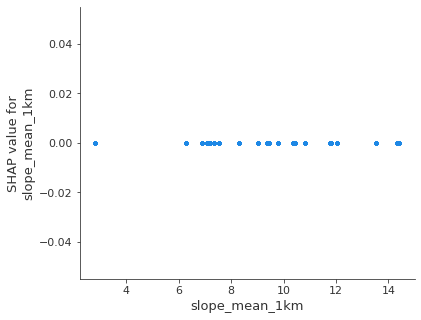

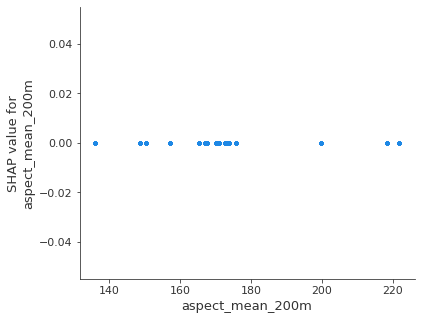

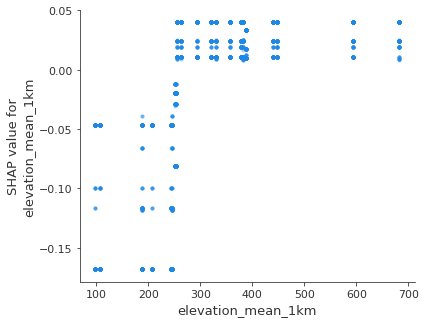

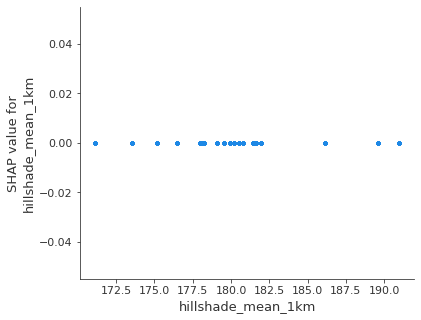

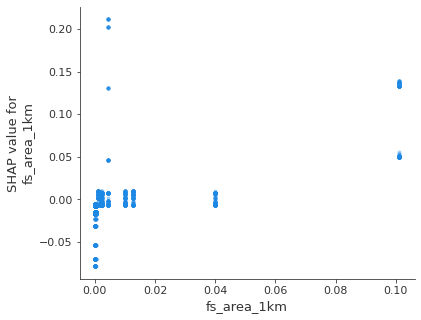

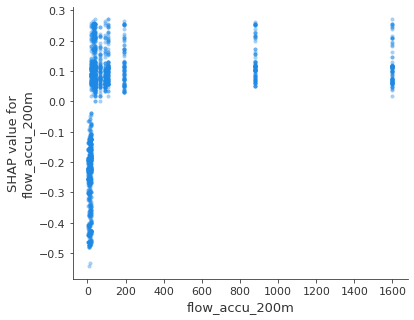

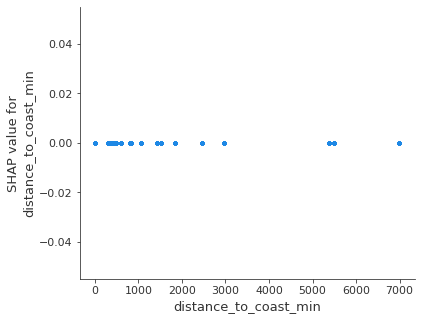

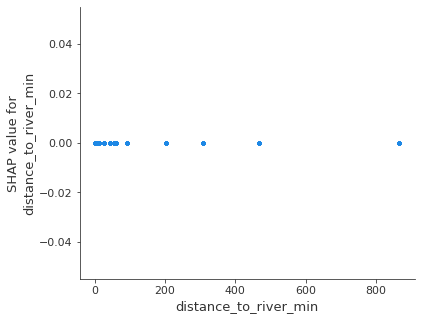

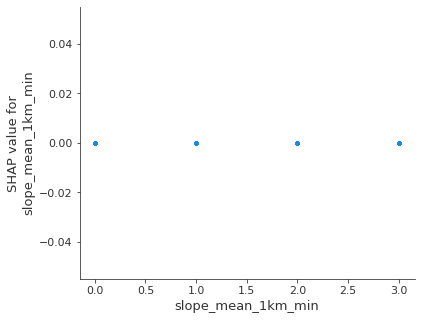

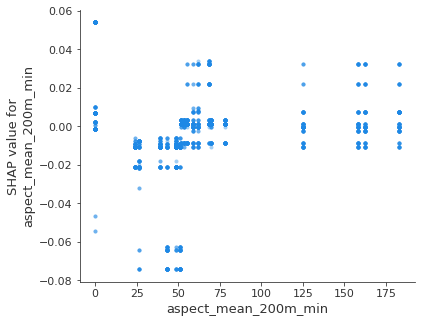

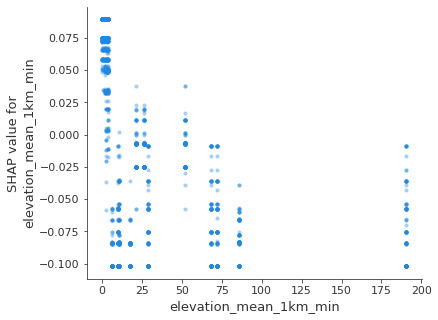

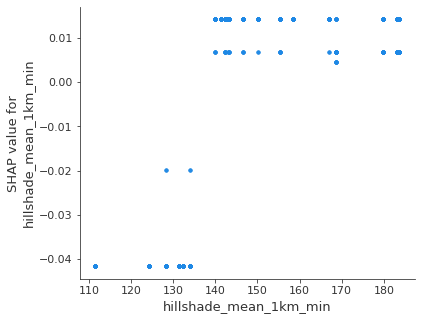

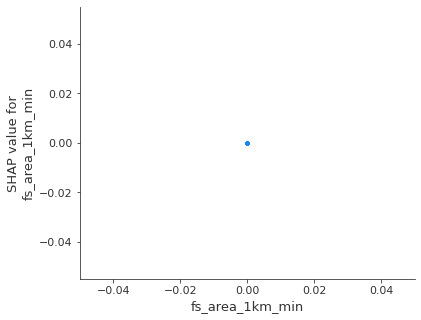

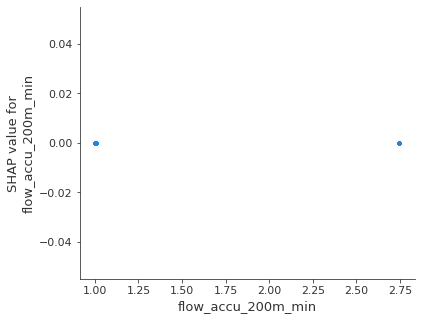

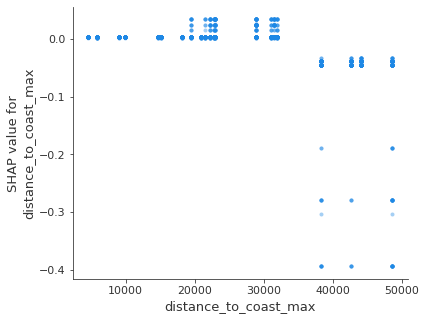

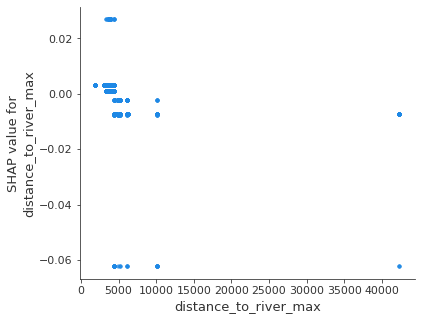

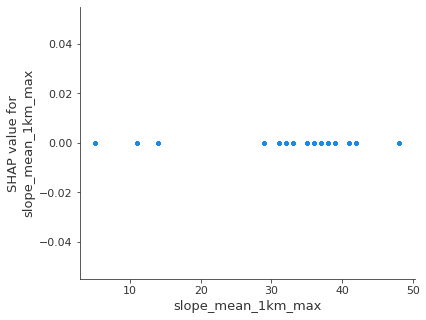

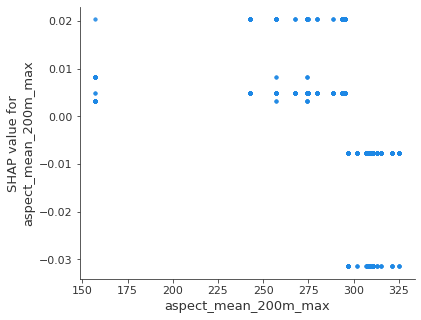

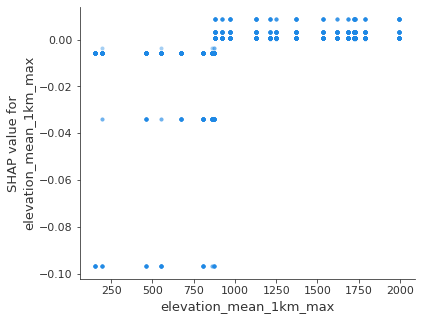

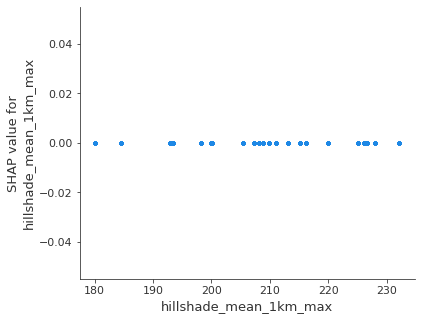

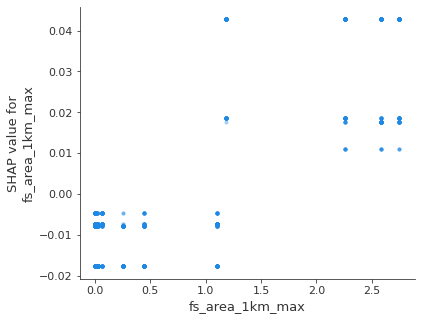

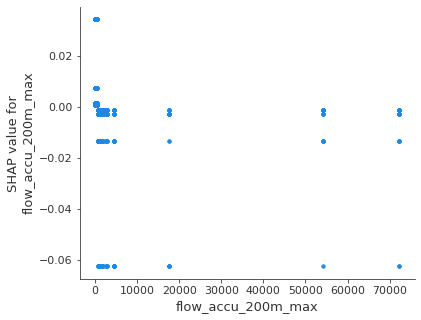

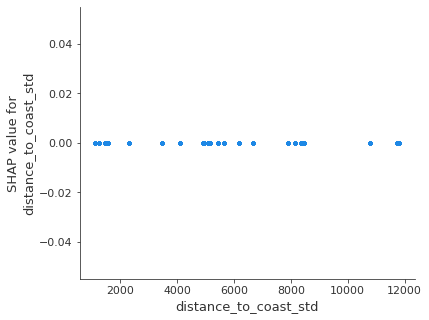

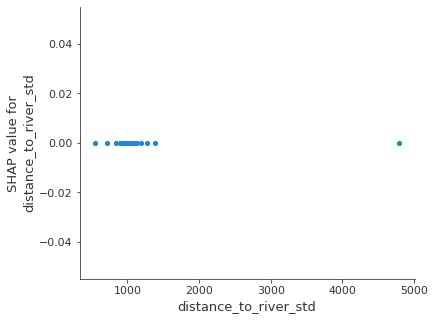

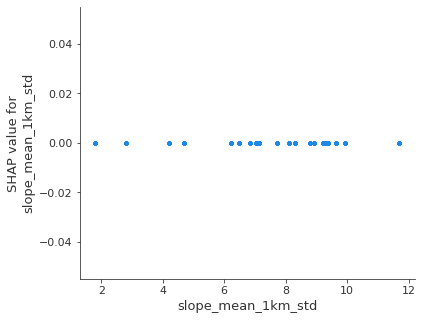

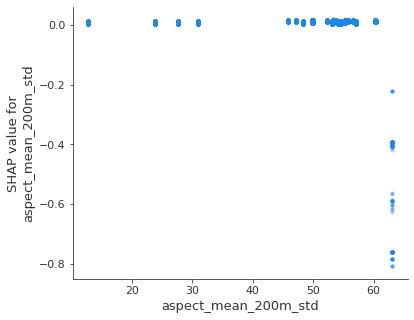

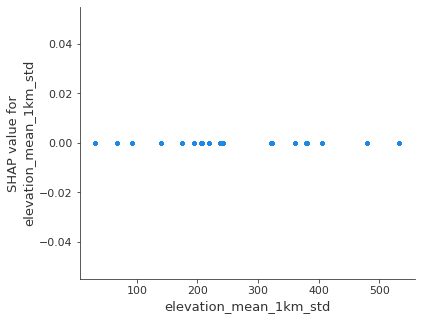

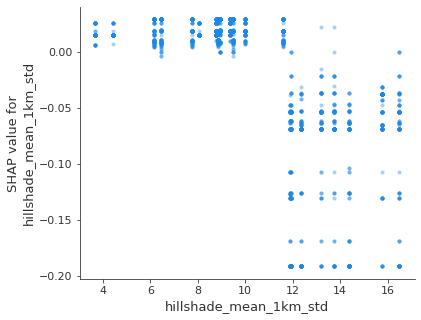

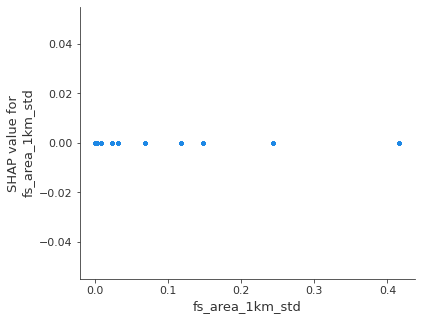

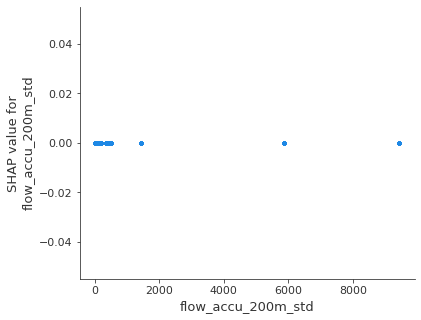

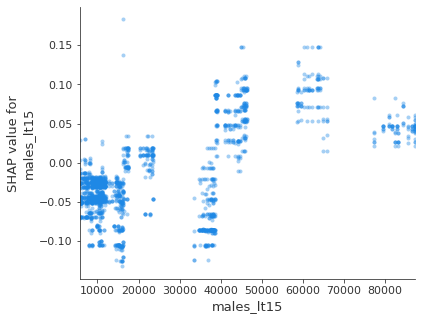

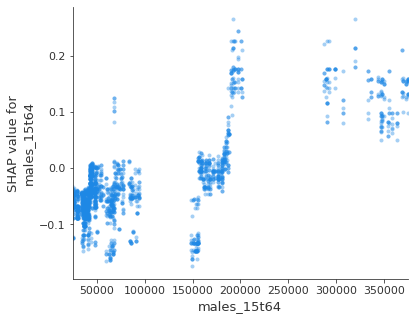

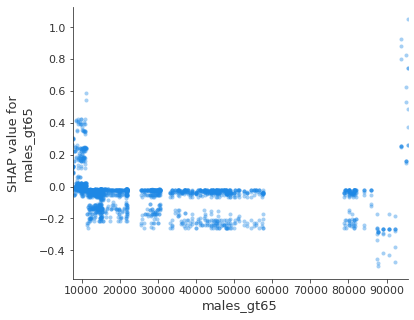

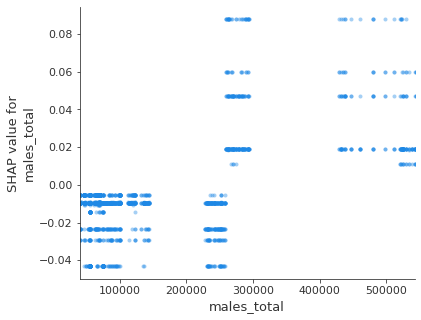

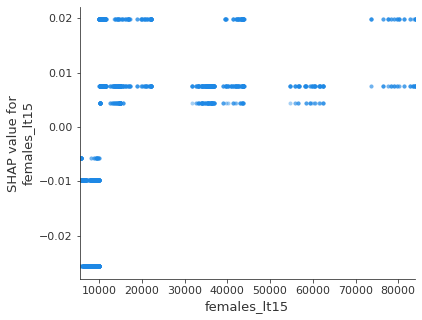

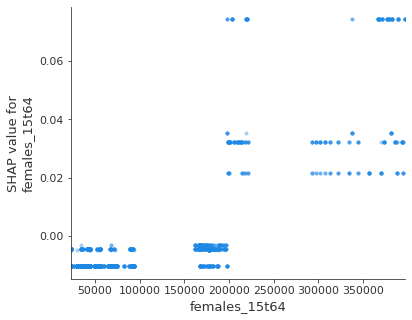

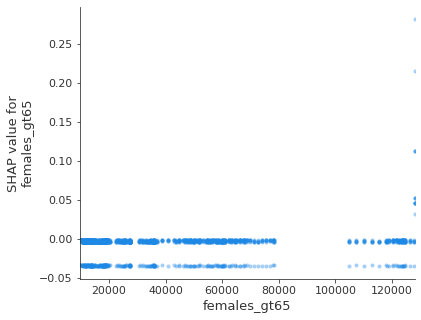

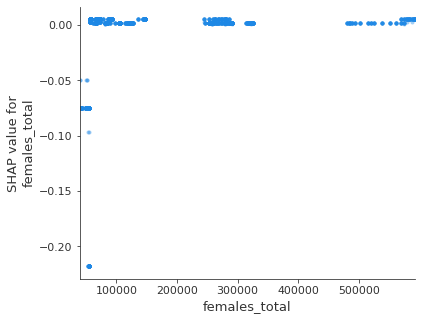

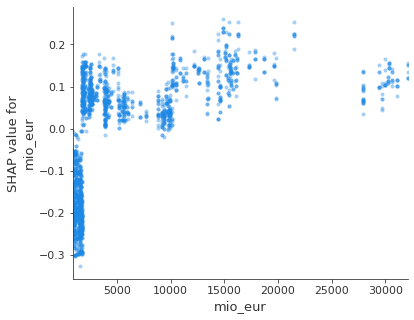

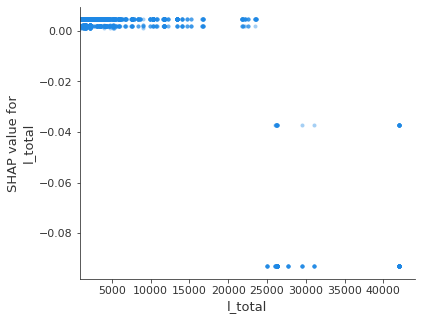

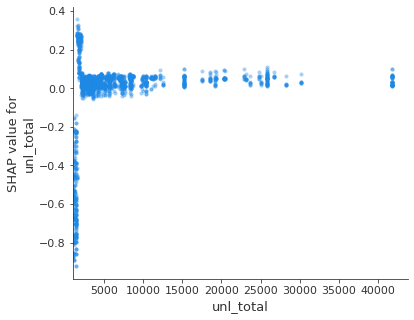

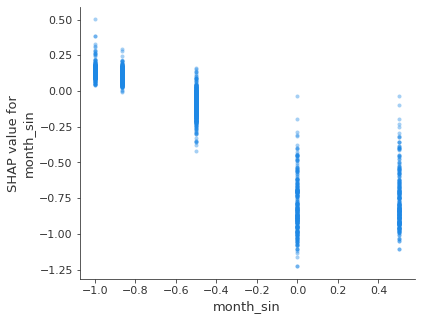

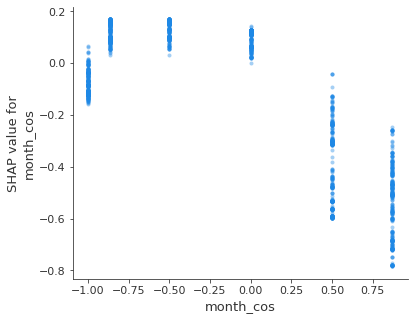

In [37]:
for ft in X_train.columns:
    shap.dependence_plot(ind = ft, shap_values = tree_shap_values.values, features = X_train, feature_names = X_train.columns, interaction_index=None, xmin="percentile(1)", xmax="percentile(99)", alpha=0.4)

In [ ]:
# params = {
#         "objective": "binary:logistic",
#         "device": "gpu", 
#         "eval_metric": "logloss",
#         "learning_rate": 0.15,
#         "min_split_loss": 0.5,
#         "max_depth": 3, 
#         "reg_alpha": 0.5,
#         "reg_lambda": 0.5,
#         "min_child_weight": 1.5,
#         "scale_pos_weight": sum_negatives/sum_positives, 
#     }

# model = xgb.XGBClassifier(**params)   
# trained_model = model.fit(X_train_imputed, y_train)

# #kernel_explainer = shap.KernelExplainer(trained_model.predict_proba, X_train_imputed, link = 'logit', feature_names=X_train.columns)
# kernel_explainer = shap.KernelExplainer(trained_model.predict_proba, shap.kmeans(X_train_imputed, 100), link = 'logit')

In [ ]:
# kernel_shap_values = kernel_explainer.shap_values(X_train_imputed)

In [ ]:
# shap_values_path = r'E:\Drive\NOA\MBD-Prediction\JRC Interpretability\Greece\data\ValuesShap\GR_OP_2010-2023_Kernel_Shapely_Values.npz'

# # np.savez(shap_values_path, *kernel_shap_values)

# kernel_shap_values = []
# loaded_shap_values = np.load(shap_values_path)

# for key in loaded_shap_values.keys():
#     kernel_shap_values.append(loaded_shap_values[key])

In [ ]:
# X_train_imputed.shape

In [ ]:
# kernel_shap_values[1].shape

In [ ]:
# shap.summary_plot(kernel_shap_values[1], feature_names = X_train.columns, features = X_train)

In [ ]:
data_train_shap

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases,month_sin,month_cos
0,EL521,2010,5,22.217953,40.552111,0.408398,0.144143,-0.235554,-0.144143,0.412976,0.140501,-0.242655,-0.140501,0.044047,0.046857,0.041740,0.046857,22.445667,6.180824,6.775942,16.031804,22.445667,7.345457,2.721929,1.588987,3.674767,7.345457,14.895562,4.451377,4.182464,9.853286,14.895562,4.901481,27.258519,2.472640,8.438265,56.295983,74.179192,558.574506,744.314815,24.810494,14.333333,19.666667,40.972222,832.120329,37.0,-11.0,48.0,5.500000,23.500000,24.000000,4.166667,1455.0,296.0,45.0,62.908014,664.0,194.0,259.0,576.0,31,36,30,12,12,1,6,7,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.0,1.000000,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,11723.0,44888.0,13557.0,70168.0,11361.0,44491.0,16024.0,71876.0,2098.63,4287.0,4163.0,0,0.5,-0.866025
1,EL522,2010,5,23.139033,40.693632,0.417461,0.158374,-0.240587,-0.158374,0.404465,0.156728,-0.228864,-0.156728,0.043854,0.042760,0.033155,0.042760,22.021724,7.924345,8.919715,16.838180,22.021724,8.176359,1.718196,2.592662,4.207480,8.176359,15.099042,4.821270,5.756189,10.522830,15.099042,6.827969,27.816719,2.203142,14.748729,43.918049,66.094267,462.422352,670.359375,22.345312,16.083333,21.166667,45.035461,888.265248,42.0,-5.0,47.0,7.166667,9.500000,27.333333,5.666667,1324.0,291.0,35.0,66.632744,587.0,184.0,280.0,547.0,31,30,30,10,10,1,6,6,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.0,1.000000,23002.186702,4365.002425,29,275.024254,879.827019,205.433801,2.743756,854.107751,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,87281.0,374669.0,80103.0,542053.0,83839.0,403005.0,104992.0,591836.0,21520.33,13373.0,15210.0,0,0.5,-0.866025
2,EL523,2010,5,22.762317,41.016275,0.392183,0.130465,-0.244458,-0.130465,0.412952,0.161777,-0.227281,-0.161777,0.037472,0.039575,0.034869,0.039575,22.303014,7.171515,8.296955,17.445933,22.303014,7.777080,0.395722,2.653680,3.611627,7.777080,15.040047,3.783619,5.475318,10.528780,15.040047,6.112391,27.085435,2.711588,17.818245,55.373941,81.347629,421.128773,742.434783,24.747826,16.041667,22.916667,44.070513,929.187899,44.0,-8.0,52.0,6.666667,9.333333,27.666667,5.333333,1381.0,286.0,41.0,63.457161,604.0,204.0,300.0,550.0,31,36,30,12,12,3,5,8,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.21562

In [ ]:
location_columns = data_train_shap.iloc[:, :5]
wnv_columns = data_train_shap['cases']

In [ ]:
wnv_columns

0       0
1       0
2       0
3       0
4       0
       ..
2151    0
2152    0
2153    0
2154    0
2155    0
Name: cases, Length: 2156, dtype: int64

In [ ]:
tree_shap_values_df = pd.DataFrame(tree_shap_values, columns=X_train.columns)
tree_shap_values_df = pd.concat([location_columns, tree_shap_values_df, wnv_columns], axis=1)

# kernel_shap_values_df = pd.DataFrame(kernel_shap_values[1], columns=X_train.columns)
# kernel_shap_values_df = pd.concat([location_columns, kernel_shap_values_df, wnv_columns], axis=1)

In [ ]:
tree_shap_values_df

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_type2,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,month_sin,month_cos,cases
0,EL521,2010,5,22.217953,40.552111,-0.210915,0.069313,-0.037522,0.001934,0.033732,0.111092,0.095656,-0.028917,-0.024023,-2.116884,-0.058193,0.194302,-0.043413,-0.247147,-0.694025,0.064605,0.097711,-0.082957,-0.115940,-0.502875,-0.472762,-0.049602,0.065357,-0.208129,-0.003410,-0.024740,-0.136871,0.032826,-0.054899,0.023320,0.075669,-0.032345,-0.013458,0.004589,0.048056,0.034025,-0.007704,-0.005946,0.038186,0.061554,0.003986,0.417712,0.017650,-0.003908,-0.122468,-0.062895,0.103320,0.0,-0.003396,0.0,0.0,-0.002722,-0.108013,0.0,-0.008008,0.073370,0.0,0.0,0.0,0.013851,-0.021659,-0.046461,0.0,-0.005209,-0.010605,-0.038328,-0.081564,-0.033984,0.0,0.025294,-0.010163,0.0,0.040107,-0.001685,-0.048601,-0.991052,0.069138,0
1,EL522,2010,5,23.139033,40.693632,-0.043631,0.045259,-0.037522,0.001934,0.033732,-0.004719,0.095656,0.037612,-0.024023,-2.150896,-0.055345,0.198259,-0.039759,-0.179948,-0.694025,0.067252,0.069479,-0.082957,-0.115940,-0.454923,-0.483048,-0.091985,0.045904,-0.081177,-0.045176,-0.020252,-0.175978,0.035084,0.057688,0.026613,0.071447,-0.013714,-0.018354,-0.000492,0.027059,0.111378,-0.007704,0.002542,0.028956,0.021047,0.021034,0.402937,0.008256,-0.003908,-0.122468,0.109817,0.125828,0.0,-0.003396,0.0,0.0,-0.002722,0.067372,0.0,0.144650,0.091463,0.0,0.0,0.0,0.013851,0.003397,0.006956,0.0,-0.005209,0.034347,0.059271,-0.129286,0.064781,0.0,0.006938,-0.010163,0.0,0.196972,-0.003011,0.151020,-0.907217,0.089856,0
2,EL523,2010,5,22.762317,41.016275,-0.054691,-0.123537,-0.029364,0.000840,0.033732,0.111092,0.171347,0.052371,-0.122200,-2.233115,0.120907,0.244649,-0.041489,-0.191319,-0.565195,0.067819,0.076663,-0.213194,-0.115940,-0.469447,-0.444221,-0.049602,0.055228,-0.111981,-0.000954,-0.144077,-0.154818,0.017656,0.120872,-0.051182,0.195773,0.019016,0.086152,0.027700,0.037712,-0.030713,-0.007704,0.011548,0.016537,0.115657,0.020343,0.444610,0.016089,-0.003908,-0.090581,0.364805,0.148170,0.0,-0.003396,0.0,0.0,-0.002722,-0.111710,0.0,-0.018513,-0.171235,0.0,0.0,0.0,-0.020408,0.003397,0.015515,0.0,-0.005209,-0.044629,-0.027030,0.133089,-0.034313,0.0,-0.007407,-0.010163,0.0,-0.151017,0.002634,-0.143295,-0.841603,0.087477,0
3,EL524,2010,5,22.109782,40.888821,-0.085291,-0.202869,-0.037522,0.001934,0.033732,0.111092,0.098506,-0.047844,-0.024023,-2.251522,-0.043822,0.240579,-0.041489,-0.179948,-0.694025,0.067819,0.097711,-0.082957,-0.115940,-0.502875,-0.485312,-0.049602,0.039086,-0.107680,-0.000954,-0.029614,-0.136651,0.035084,-0.087860,0.011257,0.064618,-0.037823,-0.014387,0.004589,0.077300,0.011463,-0.007704,0.046301,0.038186,0.043878,0.003986,0.417712,-0.181331,-0.003908,-0.105110,0.313090,0.091596,0.0,-0.003396,0.0,0.0,-0.002722,-0.112510,0.0,0.006821,0.086150,0.0,0.0,0.0,0.013851,0.001483,-0.104187,0.0,0.006755,-0.010605,-0.034724,-0.081564,-0.034313,0.0,0.025294,-0.010163,0.0,0.043055,-0.001685,-0.046197,-0.942623,0.070113,0
4,EL525,2010,5,22.442423,40.269959,-0.055773,-0.059963,-0.037522,0.000840,0.033732,-0.020810,0.092653,0.052371,-0.024023,-2.093188,-0.095939,0

In [ ]:
# kernel_shap_values_df

In [ ]:
#condition = (tree_shap_values_df['NUTS3_ID'] == 'EL301') & (tree_shap_values_df['year'] == 2010)
condition = (tree_shap_values_df['NUTS3_ID'].str.startswith('EL30')) & (tree_shap_values_df['year'] == 2023)

shap_values_df_condition = tree_shap_values_df[condition].iloc[:, 5:-1].to_numpy()

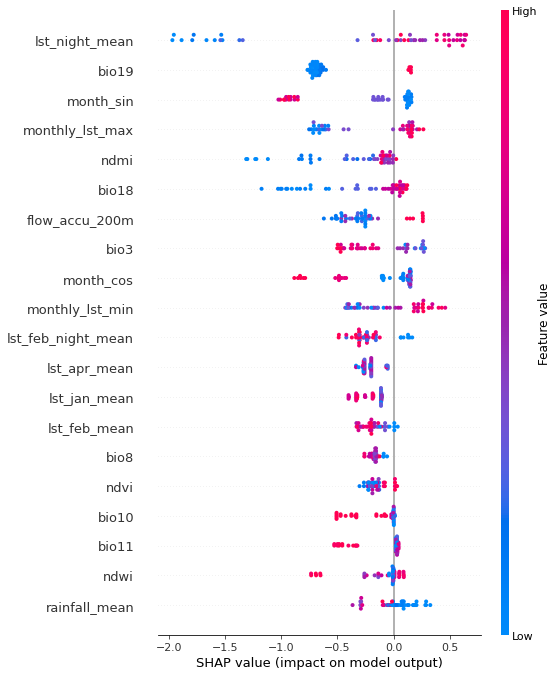

In [ ]:
shap.summary_plot(shap_values_df_condition, feature_names = X_train.columns, features = X_train[condition])